## 3.3–3.5 Detours, crossings and solution quality

**Concepts:** [Crossings & detours](../problem.md#crossings-contours-and-detours) · [HGS-CVRP](../routers.md#hgs-cvrp)

Sections covered:

- 3.3: Impact of detours on the solver’s total length
- 3.4: Comparison of B&C and HGS solutions
- 3.5: Dealing with crossings from HGS-CVRP

This is used in the paper **Flexible cable routing framework for wind farm collection system optimization**.

### Preamble

In [1]:
import lzma
import os
import shutil
import urllib.request
from pathlib import Path

import numpy as np
import polars as pl

In [2]:
from optiwindnet.db import (
    G_from_routeset,
    Method,
    NodeSet,
    RouteSet,
    database_connection,
)
from optiwindnet.svg import svgplot

In [3]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

%config InlineBackend.figure_formats = ['svg']
plt.rcParams['svg.fonttype'] = 'none'

style_file = Path('mplstyles/jupyter_dark.mplstyle')
style_file.is_file() and plt.style.use(style_file)
pub_style_file = Path('mplstyles/pdf_1col.mplstyle')
pub_style = pub_style_file if pub_style_file.is_file() else 'default'

### Setup

In [4]:
def fetch_zenodo_file(record, file_name, target_path: str = '.'):
    url = f'https://zenodo.org/records/{record}/files/{file_name}.xz?download=1'
    try:
        with (
            open(os.path.join(target_path, file_name), 'xb') as f_out,
            urllib.request.urlopen(url) as response,
            lzma.open(response) as decompressor,
        ):
            shutil.copyfileobj(decompressor, f_out)
    except FileExistsError:
        return

In [5]:
record = '19798734'
DB_FILE = 'paperdb.v4.sqlite'

In [6]:
fetch_zenodo_file(record, DB_FILE)

### Selecting _actual_ routesets

In [7]:
with database_connection(DB_FILE):
    Ns_q = NodeSet.select().where(~NodeSet.name.startswith('!'))
Ns_q.count()

69

In [8]:
entries = []
for ns in Ns_q:
    for rs in ns.routesets:
        entries.append(
            (
                ns.name,
                rs.id,
                ns.T,
                rs.capacity,
                rs.detextra,
                rs.length,
                rs.creator,
                rs.misc.get('gap', None),
            )
        )
len(entries)

1464

#### Make DataFrame

In [9]:
schema_actual = {
    'name': str,
    'id': int,
    'T': int,
    'capacity': int,
    'detextra': float,
    'length': float,
    'creator': str,
    'gap': float,
}

In [10]:
df_actual = pl.DataFrame(entries, schema=schema_actual, orient='row')

In [11]:
df_actual

name,id,T,capacity,detextra,length,creator,gap
str,i64,i64,i64,f64,f64,str,f64
"""Gode Wind 1""",1,55,5,0.000847,63626.868227,"""MILP.pyomo.cplex""",0.004949
"""Gode Wind 1""",2,55,7,null,55566.023496,"""MILP.pyomo.cplex""",0.004982
"""Gode Wind 1""",3,55,6,null,59109.208596,"""MILP.pyomo.cplex""",0.005
"""Gode Wind 1""",4,55,9,null,51675.248009,"""MILP.pyomo.cplex""",0.005
"""Gode Wind 1""",5,55,8,null,53268.425754,"""MILP.pyomo.cplex""",0.004997
…,…,…,…,…,…,…,…
"""Cazzaro-2022""",21630,50,10,0.0,7.876699,"""MILP.pyomo.cplex""",0.00496
"""Cazzaro-2022""",21631,50,11,2.2204e-16,7.71745,"""MILP.pyomo.cplex""",0.004993
"""Cazzaro-2022""",21632,50,8,0.0,8.425937,"""MILP.pyomo.cplex""",0.004999


In [12]:
df_actual['name'].value_counts()

name,count
str,u32
"""West of Duddon Sands""",22
"""Baltic Eagle""",22
"""Fecamp""",22
"""Rudong H6""",22
"""Sheringham Shoal.1_OSS""",20
…,…
"""Wikinger""",22
"""Seagreen""",22
"""Princess Amalia""",22


In [13]:
df_actual['gap'].max()

0.019817266284630097

In [14]:
df_actual['detextra'].max()

0.12263549531666174

#### group ⟨heuri, exact⟩ pairs

In [15]:
pairs_actual = []
for ns in Ns_q:
    dfn = df_actual.filter(pl.col('name') == ns.name)
    for k in range(dfn['capacity'].min(), dfn['capacity'].max() + 1):
        dfk = dfn.filter(pl.col('capacity') == k)
        if dfk.height >= 2:
            mask = pl.col('creator') == 'baselines.hgs'
            heuri = dfk.filter(mask).bottom_k(1, by='length')[0]
            exact = dfk.filter(~mask).bottom_k(1, by='gap')[0]
            if exact['gap'].item() <= 0.02:
                pairs_actual.append(
                    (
                        RouteSet.get_by_id(heuri['id'].item()),
                        RouteSet.get_by_id(exact['id'].item()),
                    )
                )
len(pairs_actual)

732

In [16]:
diffs = []
for rs_hgs, rs_bnc in pairs_actual:
    diffs.append(rs_hgs.length / rs_bnc.length - 1)

In [17]:
for (heuri, exact), diff in zip(pairs_actual, diffs):
    if diff >= 0.07:
        print(heuri.id, exact.id, exact.nodes.name)

21311 22196 Sandbank
21545 21925 Moray West.1_OSS


In [18]:
small_diffs = []
for (heuri, exact), diff in zip(pairs_actual, diffs):
    if diff <= 0.01:
        small_diffs.append((heuri.id, exact.id))
len(small_diffs)

540

0.07397519014347398


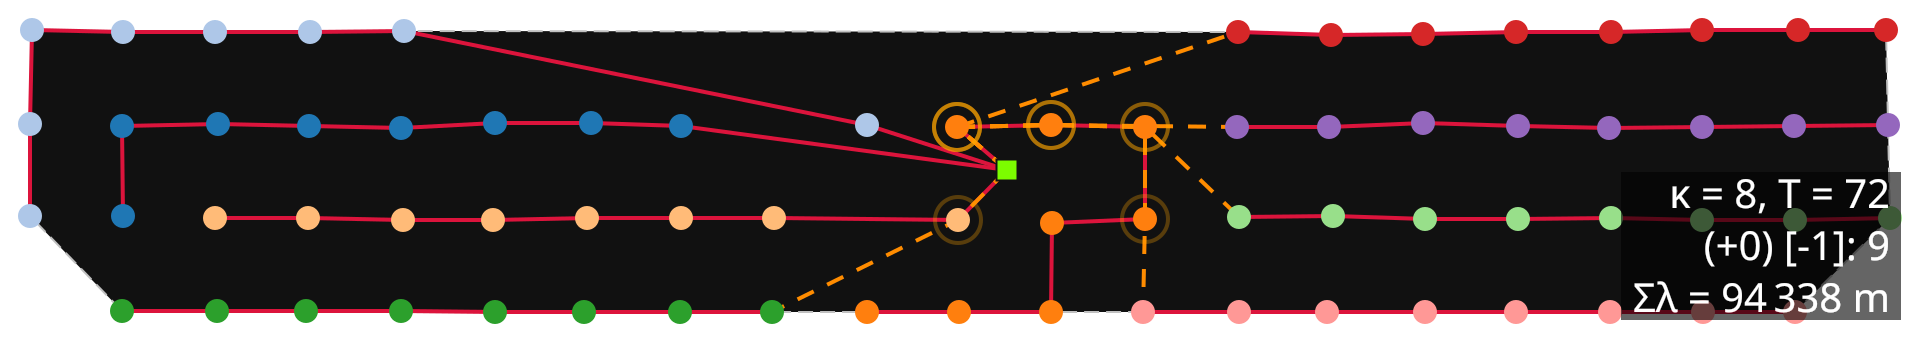

In [19]:
rs = RouteSet.get_by_id(21311)
print(rs.detextra)
svgplot(G_from_routeset(rs))

0.0013995437575948788


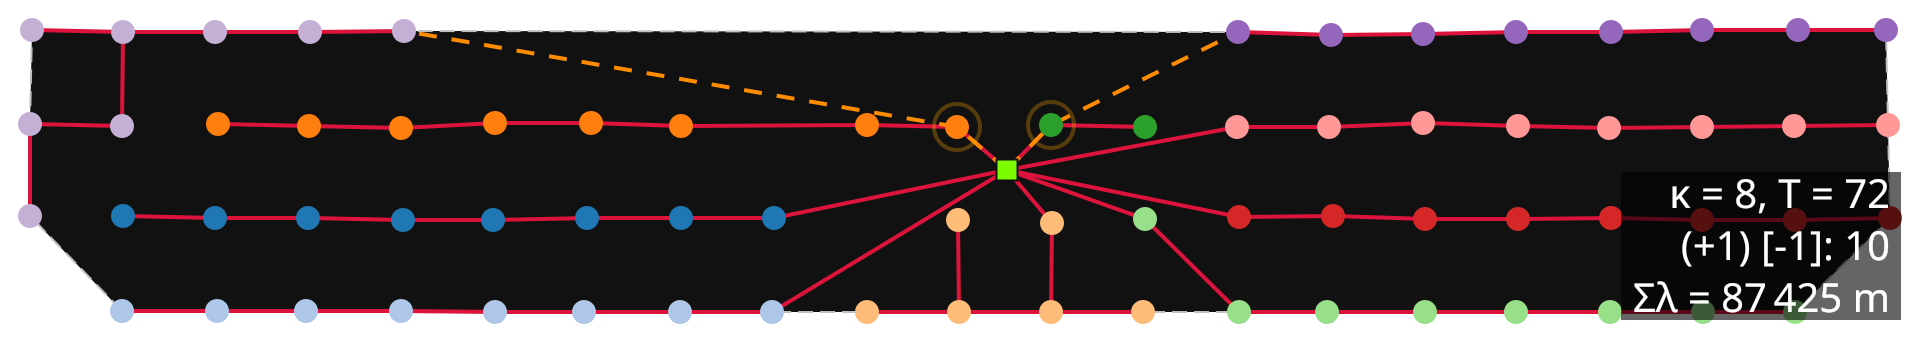

In [20]:
rs = RouteSet.get_by_id(22196)
print(rs.detextra)
svgplot(G_from_routeset(rs))

0.02038470064164777


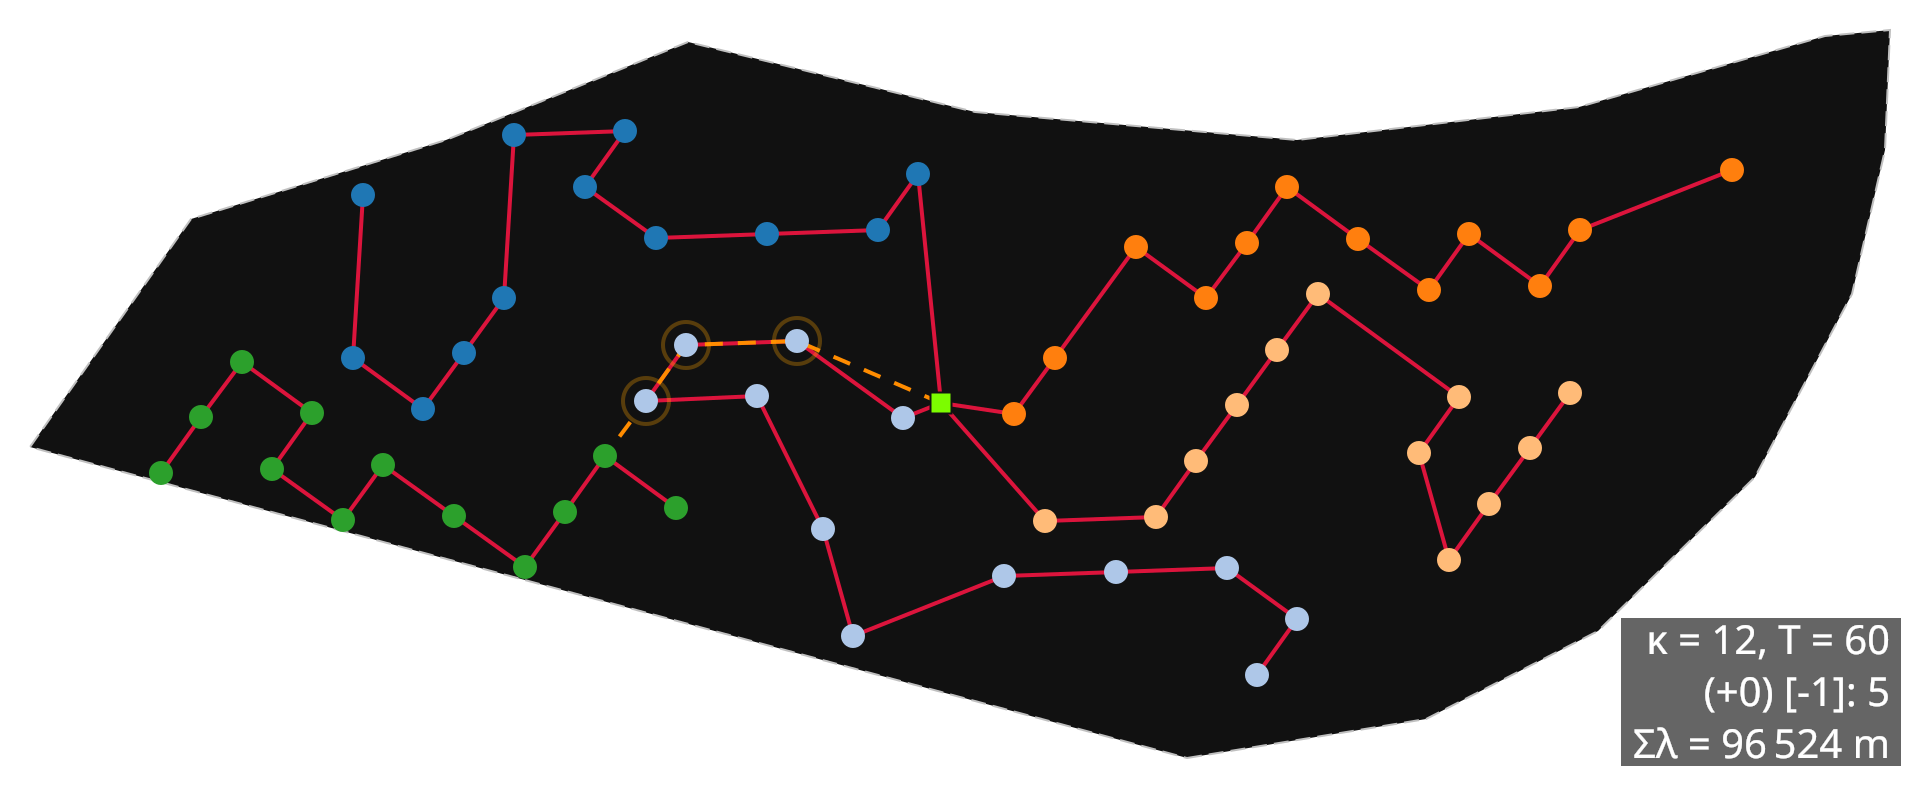

In [21]:
rs = RouteSet.get_by_id(21545)
print(rs.detextra)
svgplot(G_from_routeset(rs))

None


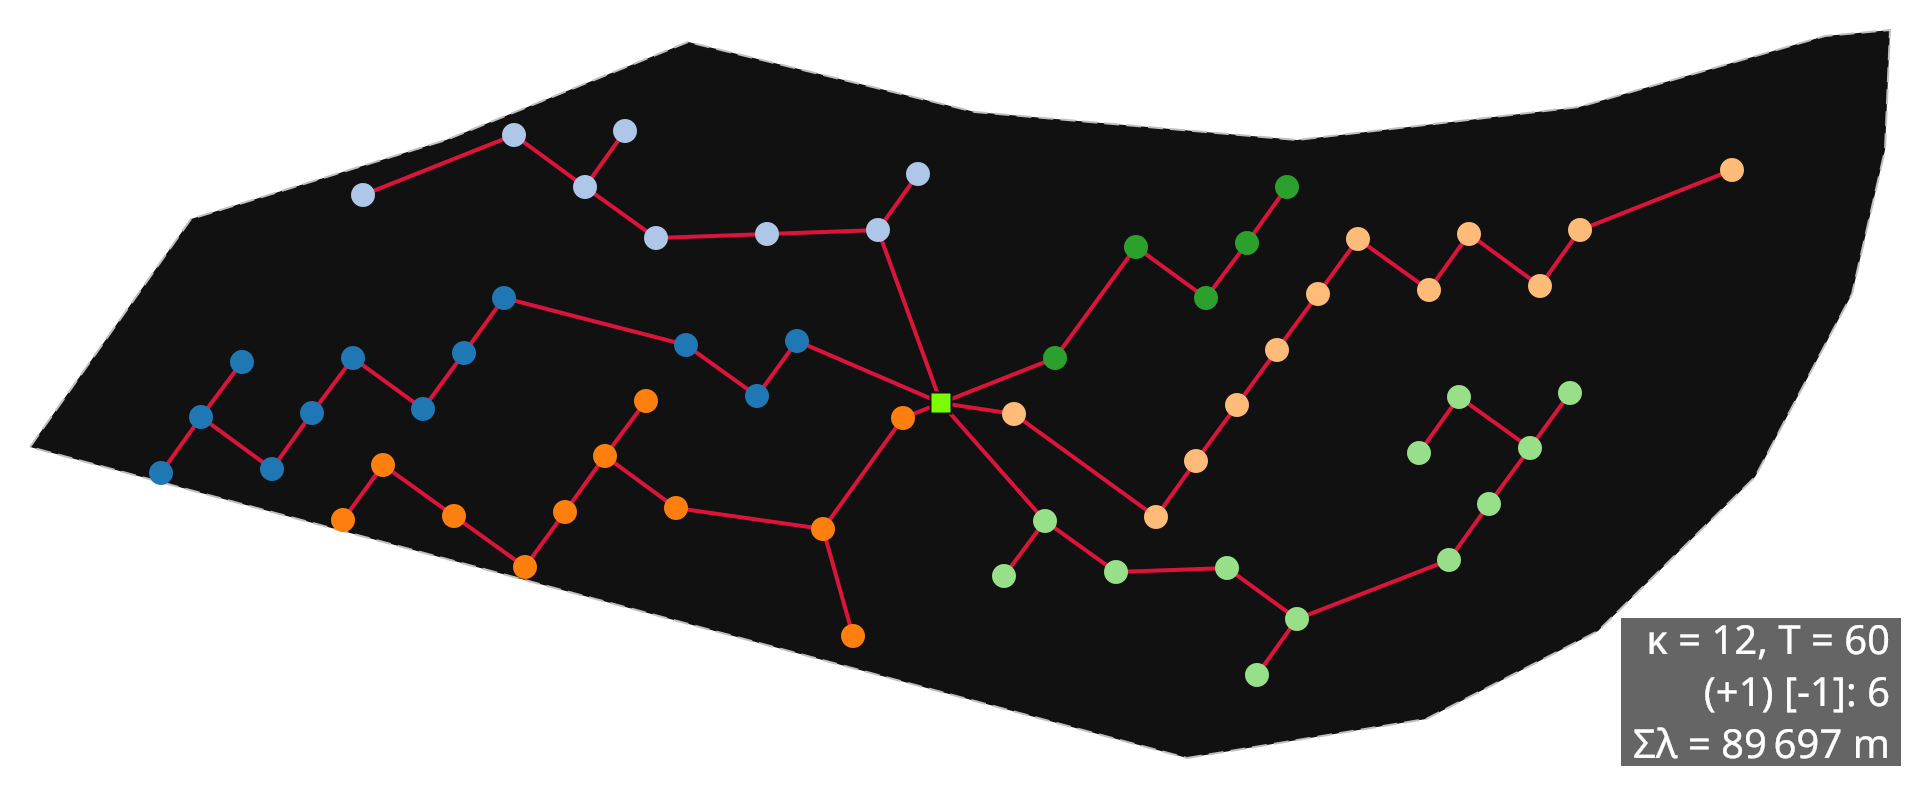

In [22]:
rs = RouteSet.get_by_id(21925)
print(rs.detextra)
svgplot(G_from_routeset(rs))

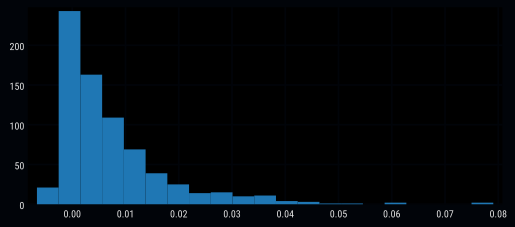

In [23]:
plt.hist(diffs, bins=21);

### HGS optimizer

#### Select HGS-CVRP entries

In [24]:
method_hgs = Method.select().where(
    Method.funname == 'hgs_cvrp', Method.options['timeLimit'] == 120
)
method_hgs.count()

2

In [25]:
for m in method_hgs:
    print(m.funname, m.options)

hgs_cvrp {'complete': False, 'lambda_': 40, 'mu': 25, 'nbClose': 5, 'nbElite': 4, 'nbGranular': 20, 'nbIter': 20000, 'scale': 10000.0, 'seed': 0, 'targetFeasible': 0.2, 'timeLimit': 120.0, 'useSwapStar': True}
hgs_cvrp {'complete': False, 'lambda_': 40, 'mu': 25, 'nbClose': 5, 'nbElite': 4, 'nbGranular': 20, 'nbIter': 20000, 'seed': 20241113, 'targetFeasible': 0.2, 'timeLimit': 120, 'useSwapStar': True}


#### synthetic instances (a single capacity per NodeSet)

In [26]:
pairs_synth = []

In [27]:
# hgs instances that were first solved by cplex
hgs_sub2 = (
    RouteSet.select()
    .join(NodeSet)
    .switch(RouteSet)
    .where(
        RouteSet.method.in_([m.digest for m in method_hgs]),
        RouteSet.misc['solver_details'].is_null(False),
        RouteSet.misc['solver_details']['incumbent_id'].is_null(False),
        NodeSet.name.startswith('!'),
        NodeSet.T >= 50,
    )
)
# keep only instances for which the exact solution is within 2% gap
for rs_hgs in hgs_sub2:
    rs_bnc = RouteSet.get_by_id(rs_hgs.misc['solver_details']['incumbent_id'])
    if rs_bnc.misc['gap'] <= 0.02:
        pairs_synth.append((rs_hgs, rs_bnc))
hgs_sub2.count(), len(pairs_synth)

(2346, 2346)

In [28]:
# hgs instances that were solved by cplex afterward
hgs_sub2_ = (
    RouteSet.select()
    .join(NodeSet)
    .switch(RouteSet)
    .where(
        RouteSet.method.in_([m.digest for m in method_hgs]),
        RouteSet.misc['solver_details'].is_null(),
        NodeSet.name.startswith('!'),
        NodeSet.T >= 50,
    )
)
# keep only instances for which the exact solution is within 2% gap
for rs_hgs in hgs_sub2_:
    if rs_hgs.nodes.routesets.count() == 1:
        # no MILP counterpart
        continue
    cplex = gurobi = None
    for rs2 in rs_hgs.nodes.routesets:
        if rs2.id == rs_hgs.id:
            continue
        if rs2.creator == 'MILP.pyomo.cplex':
            cplex = rs2
        elif rs2.creator == 'MILP.pyomo.gurobi':
            gurobi = rs2
    if gurobi and gurobi.misc['gap'] <= 0.02:
        pairs_synth.append((rs_hgs, gurobi))
    elif cplex and cplex.misc['gap'] <= 0.02:
        pairs_synth.append((rs_hgs, cplex))
hgs_sub2_.count(), len(pairs_synth)

(4033, 6379)

In [29]:
len(pairs_actual) + len(pairs_synth)

7111

#### Check if there are NodeSets counted multiple times

In [30]:
len(pairs_synth)

6379

In [31]:
once = set()
twice = set()
for rs_hgs, rs_bnc in pairs_synth:
    assert rs_hgs.nodes_id == rs_bnc.nodes_id, (rs_hgs.nodes.name, rs_bnc.nodes.name)
    if rs_hgs.nodes_id in once:
        if rs_hgs.nodes_id in twice:
            print(f'more than twice: {rs_hgs.nodes.name}')
        twice.add(rs_hgs.nodes_id)
    else:
        once.add(rs_hgs.nodes_id)
len(once), len(twice)

(6379, 0)

#### Make DataFrame

In [32]:
schema_hgs = {
    'id': int,
    'synthetic': bool,
    'T': int,
    'capacity': int,
    'detextra': float,
    'length': float,
    # incumbent=float,
    # incumbent_bound=float,
    'exact_bound': float,
    # incumbent_id=int,
}

In [33]:
data = []
for rs_hgs, rs_bnc in pairs_actual + pairs_synth:
    data.append(
        {
            'id': rs_hgs.id,
            'synthetic': rs_hgs.nodes.name[0] == '!',
            'T': rs_hgs.T,
            'capacity': rs_hgs.capacity,
            'detextra': rs_hgs.detextra,
            'length': rs_hgs.length,
            'exact_bound': rs_bnc.misc['bound'],
        }
    )
    # print(details['incumbent_id'], end=' ')
df_hgs = pl.DataFrame(data, schema=schema_hgs)

In [34]:
df_hgs.columns

['id', 'synthetic', 'T', 'capacity', 'detextra', 'length', 'exact_bound']

In [35]:
df_hgs['synthetic'].value_counts()

synthetic,count
bool,u32
false,732
true,6379


In [36]:
df_hgs['detextra'].describe()

statistic,value
str,f64
"""count""",5129.0
"""null_count""",1982.0
"""mean""",0.003079
"""std""",0.005495
"""min""",-0.018452
"""25%""",0.000774
"""50%""",0.001801
"""75%""",0.003515
"""max""",0.118956


In [37]:
detextra_hgs = np.sort(np.nan_to_num(np.clip(df_hgs['detextra'], 0.0, None), nan=0.0))

In [38]:
# Negative detextra in hgs is OK.
# It means some subtree roots chosen by PathFinder were closer to root
# than the path's head (since PathFinder relaxes the path-subtree constraint)
df_hgs.filter(pl.col('detextra') < -1e-3)

id,synthetic,T,capacity,detextra,length,exact_bound
i64,bool,i64,i64,f64,f64,f64
21006,false,60,10,-0.002975,51296.546654,49611.477292
21209,false,55,2,-0.003444,182175.265645,182804.81475
21208,false,55,4,-0.001266,99909.593562,99531.718807
21556,false,119,2,-0.017189,405793.043417,412587.411775
21557,false,119,3,-0.007867,291621.821448,292531.694887
…,…,…,…,…,…,…
16186,true,70,10,-0.009745,7.983239,7.73576
16857,true,50,4,-0.003896,8.106149,8.051141
17139,true,133,10,-0.002333,12.255932,11.63741


### B&C solver

#### Make DataFrame

In [39]:
schema_exact = {
    'id': int,
    'synthetic': bool,
    'T': int,
    'capacity': int,
    'detextra': float,
    'length': float,
    'bound': float,
}

In [40]:
data = []
for rs_hgs, rs_bnc in pairs_actual + pairs_synth:
    data.append(
        {
            'id': rs_bnc.id,
            'synthetic': rs_bnc.nodes.name[0] == '!',
            'T': rs_bnc.T,
            'capacity': rs_bnc.capacity,
            'detextra': rs_bnc.detextra,
            'length': rs_bnc.length,
            'bound': rs_bnc.misc['bound'],
        }
    )
df_BnC = pl.DataFrame(data, schema=schema_exact)

In [41]:
df_BnC.height

7111

In [42]:
df_BnC['detextra'].describe()

statistic,value
str,f64
"""count""",4949.0
"""null_count""",2162.0
"""mean""",0.002359
"""std""",0.004466
"""min""",-0.009212
"""25%""",0.000637
"""50%""",0.001591
"""75%""",0.003006
"""max""",0.122635


In [43]:
detextra_BnC = np.sort(np.nan_to_num(np.clip(df_BnC['detextra'], 0.0, None), nan=0.0))

### 3.3 Impact of detours on the solver's total length

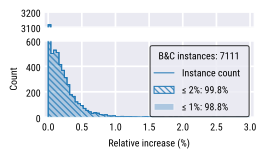

In [44]:
with plt.style.context(pub_style):
    data = 100 * detextra_BnC

    fig, (ax1, ax2) = plt.subplots(
        2, 1, height_ratios=[1, 5], figsize=(3.5, 2), facecolor='w', sharex=True
    )
    # fig.subplots_adjust(hspace=0.05)
    ax1.spines.bottom.set_visible(False)
    ax1.xaxis.tick_top()
    ax1.tick_params(labeltop=False)
    num_data = len(data)
    below1 = data <= 1
    below2 = data <= 2
    bins = np.linspace(0, 3, num=76)
    # bins = None

    # top y_axis segment
    H1, X1, art1_ = ax1.hist(
        data[below1], bins=bins, color='tab:blue', histtype='stepfilled', alpha=0.3
    )
    H2, X2, art2_ = ax1.hist(
        data[below2],
        bins=bins,
        edgecolor='tab:blue',
        histtype='stepfilled',
        hatch=r'\\\\',
        facecolor='none',
    )
    H, X, art_ = ax1.hist(data, bins=bins, color='tab:blue', histtype='step')

    # main y_axis segment
    H1, X1, art1_ = ax2.hist(
        data[below1], bins=bins, color='tab:blue', histtype='stepfilled', alpha=0.3
    )
    H2, X2, art2_ = ax2.hist(
        data[below2],
        bins=bins,
        edgecolor='tab:blue',
        histtype='stepfilled',
        hatch=r'\\\\',
        facecolor='none',
    )
    H, X, art_ = ax2.hist(data, bins=bins, color='tab:blue', histtype='step')

    ax1.set_ylim(3100, 3200)  # outliers only
    ax2.set_ylim(0, 600)  # most of the data

    C1, C2 = H1.sum(), H2.sum()
    leg = ax2.legend(  # the empty Line2D is a hack to get a line instead of a patch
        [Line2D([], []), art2_[0], art1_[0]],
        [
            'Instance count',
            f'≤ 2%: {100 * C2 / num_data:.1f}%',
            f'≤ 1%: {100 * C1 / num_data:.1f}%',
        ],
        title=f'B&C instances: {num_data}',
    )
    ax2.set_ylabel('Count')
    ax2.set_xlabel('Relative increase (%)')
    leg.legend_handles[0] = Line2D([], [])
    ax1.figure.savefig('fig_detextra_BnC.pdf', transparent=False)

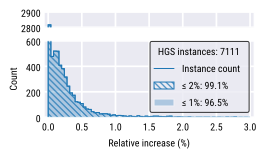

In [45]:
with plt.style.context(pub_style):
    # with plt.style.context('pub_paperfarm'):
    # if True:
    data = 100 * detextra_hgs

    fig, (ax1, ax2) = plt.subplots(
        2, 1, height_ratios=[1, 5], figsize=(3.5, 2), facecolor='w', sharex=True
    )
    # fig.subplots_adjust(hspace=0.05)
    ax1.spines.bottom.set_visible(False)
    ax1.xaxis.tick_top()
    ax1.tick_params(labeltop=False)
    num_data = len(data)
    below1 = data <= 1
    below2 = data <= 2
    bins = np.linspace(0, 3, num=76)
    # bins = None

    # top y_axis segment
    H1, X1, art1_ = ax1.hist(
        data[below1], bins=bins, color='tab:blue', histtype='stepfilled', alpha=0.3
    )
    H2, X2, art2_ = ax1.hist(
        data[below2],
        bins=bins,
        edgecolor='tab:blue',
        histtype='stepfilled',
        hatch=r'\\\\',
        facecolor='none',
    )
    H, X, art_ = ax1.hist(data, bins=bins, color='tab:blue', histtype='step')

    # main y_axis segment
    H1, X1, art1_ = ax2.hist(
        data[below1], bins=bins, color='tab:blue', histtype='stepfilled', alpha=0.3
    )
    H2, X2, art2_ = ax2.hist(
        data[below2],
        bins=bins,
        edgecolor='tab:blue',
        histtype='stepfilled',
        hatch=r'\\\\',
        facecolor='none',
    )
    H, X, art_ = ax2.hist(data, bins=bins, color='tab:blue', histtype='step')

    ax1.set_ylim(2800, 2900)  # outliers only
    ax2.set_ylim(0, 600)  # most of the data

    C1, C2 = H1.sum(), H2.sum()
    leg = ax2.legend(  # the empty Line2D is a hack to get a line instead of a patch
        [Line2D([], []), art2_[0], art1_[0]],
        [
            'Instance count',
            f'≤ 2%: {100 * C2 / num_data:.1f}%',
            f'≤ 1%: {100 * C1 / num_data:.1f}%',
        ],
        title=f'HGS instances: {num_data}',
    )
    ax2.set_ylabel('Count')
    ax2.set_xlabel('Relative increase (%)')
    leg.legend_handles[0] = Line2D([], [])
    ax1.figure.savefig('fig_detextra_HGS.pdf', transparent=False)

### 3.4 Comparison of B&C and HGS solutions

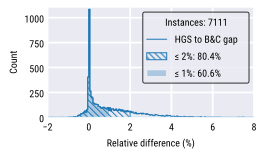

In [46]:
with plt.style.context(pub_style):
    data_HGSvsBnC_gap = 1 - df_BnC['length'] / df_hgs['length']
    data = 100 * data_HGSvsBnC_gap.to_numpy()

    fig, ax = plt.subplots(facecolor='w', figsize=(3.5, 2))
    num_data = len(data)
    below1 = data <= 1
    below2 = data <= 2
    elsewhere = data > 2
    bins = np.linspace(-2, 8, num=201)

    # main y_axis segment
    H1, X1, art1_ = ax.hist(
        data[below1], bins=bins, color='tab:blue', histtype='stepfilled', alpha=0.3
    )
    H2, X2, art2_ = ax.hist(
        data[below2],
        bins=bins,
        edgecolor='tab:blue',
        histtype='stepfilled',
        hatch=r'\\\\',
        facecolor='none',
    )
    H, X, art_ = ax.hist(data, bins=bins, color='tab:blue', histtype='step')

    C1, C2 = H1.sum(), H2.sum()
    leg = ax.legend(  # the empty Line2D is a hack to get a line instead of a patch
        [Line2D([], []), art2_[0], art1_[0]],
        [
            'HGS to B&C gap',
            f'≤ 2%: {100 * C2 / num_data:.1f}%',
            f'≤ 1%: {100 * C1 / num_data:.1f}%',
        ],
        title=f'Instances: {num_data}',
    )
    ax.set_ylabel('Count')
    ax.set_xlabel('Relative difference (%)')
    leg.legend_handles[0] = Line2D([], [])
    ax.set_xlim(-2, 8)
    ax.figure.savefig('fig_HGS_to_BnC_gap.pdf', transparent=False)

### 3.5 Dealing with crossings from HGS-CVRP

#### Select HGS-CVRP entries

In [47]:
df_hgs.height

7111

In [48]:
method_hgs = Method.select().where(
    Method.funname == 'hgs_cvrp', Method.options['timeLimit'] == 120
)

In [49]:
method_hgs.count()

2

In [50]:
hgs_all = RouteSet.select().where(RouteSet.method.in_([m.digest for m in method_hgs]))
hgs_all.count()

7044

In [51]:
hgs_invalid = 0  # routeset.valid removed from the schema
hgs_invalid

0

In [52]:
# just the instances repaired after the first hgs run
hgs_repaired = hgs_all.where(
    RouteSet.misc['repaired'].is_null(False),
    RouteSet.misc['hgs_reruns'].is_null(),
)
hgs_repaired.count()

332

In [53]:
hgs_reruns = hgs_all.where(
    RouteSet.misc['hgs_reruns'].is_null(False),
)
hgs_reruns.count()

98

#### Statistics

In [54]:
hgs_all = RouteSet.select().where(RouteSet.creator == 'baselines.hgs')
hgs_all.count()

7111

In [55]:
# just the instances repaired after the first hgs run
hgs_repaired = hgs_all.where(
    RouteSet.misc['repaired'].is_null(False),
    RouteSet.misc['hgs_reruns'].is_null(),
)
hgs_repaired.count()

332

In [56]:
hgs_reruns = hgs_all.where(
    RouteSet.misc['hgs_reruns'].is_null(False),
)
hgs_reruns.count()

98

In [57]:
(hgs_repaired.count() + hgs_reruns.count()) / hgs_all.count()

0.06046969483898186

In [58]:
hgs_repaired.count() / hgs_all.count()

0.04668822950358599

In [59]:
hgs_reruns.count() / hgs_all.count()

0.013781465335395865

#### Examining re-runs

In [60]:
subcounts = []
for reruns in range(1, 10):
    count = hgs_reruns.where(RouteSet.misc['hgs_reruns'] == reruns).count()
    subcounts.append(count)
    print(reruns, count, count / hgs_all.count())

1 81 0.011390802981296582
2 12 0.0016875263675994938
3 2 0.0002812543945999156
4 1 0.0001406271972999578
5 2 0.0002812543945999156
6 0 0.0
7 0 0.0
8 0 0.0
9 0 0.0


In [61]:
total = sum(subcounts)
for reruns, count in zip(range(1, 10), subcounts):
    print(reruns, f'{100 * count / total:.1f}%')

1 82.7%
2 12.2%
3 2.0%
4 1.0%
5 2.0%
6 0.0%
7 0.0%
8 0.0%
9 0.0%
